In [1]:
pip install pandas pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.5 MB/s eta 0:00:00


In [51]:
import pandas as pd
import pm4py
import time
from IPython.display import Image, display
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator

In [64]:
# ==========================================
# 1. Data Loading & Preprocessing
# ==========================================
print("1. Starting Data Loading & Preprocessing")

file_path = 'PPM_Event_Log_ue31delete.csv'
df = pd.read_csv(file_path)

# Rename columns to match pm4py standard format (Case ID, Activity, Timestamp)
df.rename(columns={
    'Case_ID': 'case:concept:name',
    'Activity': 'concept:name',
    'Time': 'time:timestamp'
}, inplace=True)

# Convert the Time column (in seconds) to a Datetime format recognized by pm4py
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], unit='s', origin='unix')

# Convert the dataframe to a pm4py event log object
log = pm4py.format_dataframe(df, case_id='case:concept:name',
                             activity_key='concept:name',
                             timestamp_key='time:timestamp')
print(f"-> Preprocessing completed. Total events: {len(df)}")

1. Starting Data Loading & Preprocessing
-> Preprocessing completed. Total events: 287987


In [65]:
# ==========================================
# 2. Data Anomaly Diagnosis (Tx/Rx Inversion Check)
# ==========================================
print("\n2. Diagnosing Data Anomalies (Physical Tx/Rx Inversion)")
# Check if the logical rule (Tx must precede Rx) is violated in the event log
sequences = df.groupby('case:concept:name')['concept:name'].apply(list).reset_index()

def check_strict_tx_rx(seq):
    if 'DL_RLC_Tx' in seq and 'DL_RLC_Rx' in seq:
        if seq.index('DL_RLC_Tx') < seq.index('DL_RLC_Rx'):
            return "Perfect Fit (Tx -> Rx)"
        else:
            return "Violation (Rx -> Tx Inversion)"
    else:
        return "Failed before Tx/Rx"

sequences['Compliance'] = sequences['concept:name'].apply(check_strict_tx_rx)
compliance_counts = sequences['Compliance'].value_counts()

reached_cases = compliance_counts.get('Perfect Fit (Tx -> Rx)', 0) + compliance_counts.get('Violation (Rx -> Tx Inversion)', 0)
inverted_cases = compliance_counts.get('Violation (Rx -> Tx Inversion)', 0)

print(f"-> Total cases reaching RLC Tx/Rx: {reached_cases}")
if reached_cases > 0:
    print(f"-> Physical Anomaly (Rx -> Tx Inversion) ratio: {(inverted_cases/reached_cases)*100:.2f}%")


2. Diagnosing Data Anomalies (Physical Tx/Rx Inversion)
-> Total cases reaching RLC Tx/Rx: 23992
-> Physical Anomaly (Rx -> Tx Inversion) ratio: 55.18%



3. Performing Process Discovery (Inductive Miner)
-> Process model derived successfully.
-> Process map image generated. Displaying below:


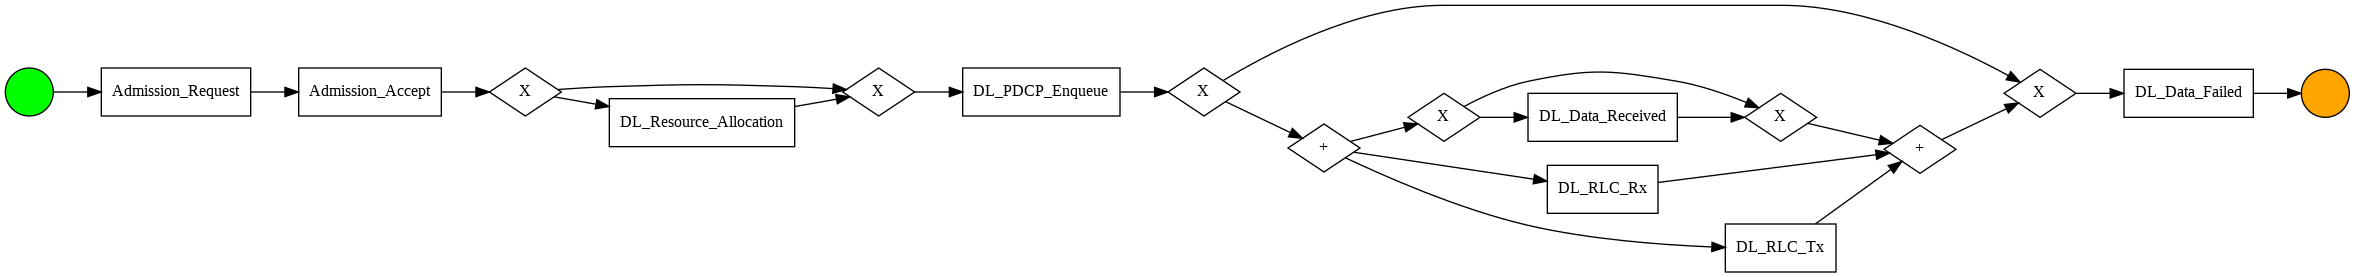

In [66]:
# ==========================================
# 3. Process Discovery & Visualization
# ==========================================
print("\n3. Performing Process Discovery (Inductive Miner)")
# Filter out minor exceptional flows using a noise_threshold (e.g., 0.2) to extract the main backbone
process_tree = pm4py.discover_process_tree_inductive(log, noise_threshold=0.2)

# Generate BPMN and Petri Net models from the process tree
bpmn_model = pm4py.convert_to_bpmn(process_tree)
net, initial_marking, final_marking = pm4py.convert_to_petri_net(process_tree)

print("-> Process model derived successfully.")

# Save the BPMN visualization as a PNG file and display it inline in the Jupyter Notebook
output_image_path = "process_map_bpmn.png"
pm4py.save_vis_bpmn(bpmn_model, output_image_path)
print("-> Process map image generated. Displaying below:")
display(Image(filename=output_image_path))

In [67]:
# ==========================================
# 4. Conformance Checking (Fitness & Precision)
# ==========================================
print("\n4. Performing Conformance Checking (Fitness & Precision)")
sampled_log = pm4py.sample_cases(log, 1000)

# Calculate Fitness (Token-based alignment)
alignments = pm4py.conformance_diagnostics_alignments(sampled_log, net, initial_marking, final_marking)
avg_fitness = sum(trace['fitness'] for trace in alignments) / len(alignments)

# Calculate Precision (ETConformance)
precision = precision_evaluator.apply(sampled_log, net, initial_marking, final_marking, variant=precision_evaluator.Variants.ALIGN_ETCONFORMANCE)

print(f"-> Average Model Fitness: {avg_fitness:.4f}")
print(f"-> Model Precision: {precision:.4f}")


4. Performing Conformance Checking (Fitness & Precision)


aligning log, completed variants ::   0%|          | 0/8 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/13 [00:00<?, ?it/s]

-> Average Model Fitness: 0.9820
-> Model Precision: 0.7072


In [68]:
# ==========================================
# 5. Performance Analysis (Bottleneck Identification)
# ==========================================
print("\n5. Performing Performance Analysis (Bottleneck Identification)")
# Calculate the average sojourn time (waiting time) between activities
perf_dfg, start_activities, end_activities = pm4py.discover_performance_dfg(log)

print("-> Top 5 bottlenecks (Average waiting time in seconds):")
sorted_perf = sorted(perf_dfg.items(), key=lambda item: item[1]['mean'], reverse=True)
for (act1, act2), metrics in sorted_perf[:10]:
    print(f"   [{act1}] ➔ [{act2}] : Average {metrics['mean']:.4f} sec")


5. Performing Performance Analysis (Bottleneck Identification)
-> Top 5 bottlenecks (Average waiting time in seconds):
   [Admission_Accept] ➔ [DL_PDCP_Enqueue] : Average 0.6823 sec
   [Admission_Accept] ➔ [DL_Resource_Allocation] : Average 0.6355 sec
   [DL_RLC_Tx] ➔ [DL_Data_Received] : Average 0.1836 sec
   [DL_RLC_Rx] ➔ [DL_Data_Received] : Average 0.1817 sec
   [DL_PDCP_Enqueue] ➔ [DL_Data_Failed] : Average 0.1000 sec
   [DL_RLC_Rx] ➔ [DL_Data_Failed] : Average 0.0998 sec
   [DL_RLC_Tx] ➔ [DL_Data_Failed] : Average 0.0998 sec
   [DL_Resource_Allocation] ➔ [DL_PDCP_Enqueue] : Average 0.0486 sec
   [DL_Resource_Allocation] ➔ [DL_Data_Received] : Average 0.0040 sec
   [DL_Data_Received] ➔ [DL_PDCP_Enqueue] : Average 0.0036 sec


In [69]:
# ==========================================
# 6. Variant Analysis (Success vs. Failure Paths)
# ==========================================
print("\n6. Analyzing Process Variants (Success vs. Failure Paths)...")

# Extract unique Case IDs based on their final outcome (Received vs. Failed)
success_case_ids = df[df['concept:name'] == 'DL_Data_Received']['case:concept:name'].unique()
failed_case_ids = df[df['concept:name'] == 'DL_Data_Failed']['case:concept:name'].unique()

# Filter the dataframe for successful and failed cases
success_df = df[df['case:concept:name'].isin(success_case_ids)]
failed_df = df[df['case:concept:name'].isin(failed_case_ids)]

# Calculate frequencies and percentages of paths for Successful cases
print("\n[Top Happy Paths (Successful Cases)]")
success_paths = success_df.groupby('case:concept:name')['concept:name'].apply(lambda x: ' ➔ '.join(x))
success_variants = success_paths.value_counts(normalize=True) * 100
for path, percentage in success_variants.head(10).items(): # Top 3 paths
    print(f"   - {percentage:.2f}% : {path}")

# Calculate frequencies and percentages of paths for Failed cases
print("\n[Top Failed Paths (Failed Cases)]")
failed_paths = failed_df.groupby('case:concept:name')['concept:name'].apply(lambda x: ' ➔ '.join(x))
failed_variants = failed_paths.value_counts(normalize=True) * 100
for path, percentage in failed_variants.head(10).items(): # Top 3 paths
    print(f"   - {percentage:.2f}% : {path}")


6. Analyzing Process Variants (Success vs. Failure Paths)...

[Top Happy Paths (Successful Cases)]
   - 52.23% : Admission_Request ➔ Admission_Accept ➔ DL_Resource_Allocation ➔ DL_PDCP_Enqueue ➔ DL_RLC_Rx ➔ DL_RLC_Tx ➔ DL_Data_Received
   - 42.30% : Admission_Request ➔ Admission_Accept ➔ DL_Resource_Allocation ➔ DL_PDCP_Enqueue ➔ DL_RLC_Tx ➔ DL_RLC_Rx ➔ DL_Data_Received
   - 2.78% : Admission_Request ➔ Admission_Accept ➔ DL_Resource_Allocation ➔ DL_Data_Received ➔ DL_PDCP_Enqueue ➔ DL_RLC_Rx ➔ DL_RLC_Tx
   - 2.27% : Admission_Request ➔ Admission_Accept ➔ DL_Resource_Allocation ➔ DL_Data_Received ➔ DL_PDCP_Enqueue ➔ DL_RLC_Tx ➔ DL_RLC_Rx
   - 0.35% : Admission_Request ➔ Admission_Accept ➔ DL_PDCP_Enqueue ➔ DL_RLC_Tx ➔ DL_Resource_Allocation ➔ DL_RLC_Rx ➔ DL_Data_Received
   - 0.08% : Admission_Request ➔ Admission_Accept ➔ DL_Resource_Allocation ➔ DL_PDCP_Enqueue ➔ DL_RLC_Rx ➔ DL_Data_Received ➔ DL_RLC_Tx

[Top Failed Paths (Failed Cases)]
   - 66.95% : Admission_Request ➔ Admission_Acc